# Question 1: Load the Digits Dataset

Load the digits dataset from sklearn and explore its properties.
The dataset contains 8x8 images of handwritten digits (0-9).

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Load the dataset
digits = load_digits()

# Explore properties
print(f"Dataset shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Classes: {np.unique(digits.target)}")

X = digits.data
y = digits.target

Dataset shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


# Question 2: Dataset Splitting (1 mark)

Divide the dataset into training (70%), validation (15%), and test (15%) sets.
Use random_state for reproducibility.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train size: 1257
Validation size: 270
Test size: 270


# Question 3: Neural Network Design from Scratch (5 marks)

Implement a fully connected feedforward neural network from scratch using NumPy.
Architecture:
- Input layer: 64 features (8x8 pixels)
- Hidden layer 1: 128 neurons with ReLU activation and dropout
- Hidden layer 2: 64 neurons with ReLU activation and dropout
- Output layer: 10 neurons with softmax activation

Key implementations:
- Softmax activation function
- Gradient through softmax
- Dropout regularization

In [3]:
class FeedforwardNeuralNetwork:
    def __init__(
        self,
        num_input_features,
        num_hidden_units_layer1,
        num_hidden_units_layer2,
        num_output_classes,
        dropout_probability=0.2
    ):
        self.W1 = np.random.randn(num_input_features, num_hidden_units_layer1) * 0.01
        self.b1 = np.zeros((1, num_hidden_units_layer1))
        self.W2 = np.random.randn(num_hidden_units_layer1, num_hidden_units_layer2) * 0.01
        self.b2 = np.zeros((1, num_hidden_units_layer2))
        self.W3 = np.random.randn(num_hidden_units_layer2, num_output_classes) * 0.01
        self.b3 = np.zeros((1, num_output_classes))
        self.dropout_probability = dropout_probability

    def relu(self, pre_activation):
        return np.maximum(0, pre_activation)

    def relu_derivative(self, pre_activation):
        return (pre_activation > 0).astype(float)

    def softmax(self, logits):
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    def dropout(self, activations, dropout_probability):
        mask = (np.random.rand(*activations.shape) > dropout_probability).astype(float)
        return (activations * mask) / (1 - dropout_probability), mask

    def forward(self, input_batch, training=True):
        self.Z1 = np.dot(input_batch, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        if training:
            self.A1, self.D1 = self.dropout(self.A1, self.dropout_probability)
            
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.relu(self.Z2)
        if training:
            self.A2, self.D2 = self.dropout(self.A2, self.dropout_probability)
            
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.softmax(self.Z3)
        return self.A3

    def backward(self, input_batch, target_labels):
        m = target_labels.shape[0]
        
        # Output layer
        dZ3 = self.A3 - target_labels
        self.dW3 = np.dot(self.A2.T, dZ3) / m
        self.db3 = np.sum(dZ3, axis=0, keepdims=True) / m
        
        # Hidden layer 2
        dA2 = np.dot(dZ3, self.W3.T)
        dA2 = dA2 * self.D2 / (1 - self.dropout_probability)
        dZ2 = dA2 * self.relu_derivative(self.Z2)
        self.dW2 = np.dot(self.A1.T, dZ2) / m
        self.db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        # Hidden layer 1
        dA1 = np.dot(dZ2, self.W2.T)
        dA1 = dA1 * self.D1 / (1 - self.dropout_probability)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        self.dW1 = np.dot(input_batch.T, dZ1) / m
        self.db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    def update_parameters(self, learning_rate):
        self.W1 -= learning_rate * self.dW1
        self.b1 -= learning_rate * self.db1
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2
        self.W3 -= learning_rate * self.dW3
        self.b3 -= learning_rate * self.db3

    def predict(self, input_batch):
        probabilities = self.forward(input_batch, training=False)
        return np.argmax(probabilities, axis=1)

# Question 4: Loss Function Implementation (1 marks)

In [4]:
def categorical_cross_entropy(Y_pred, Y_true):
    m = Y_true.shape[0]
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)
    loss = -np.sum(Y_true * np.log(Y_pred)) / m
    return loss

# Question 5: Training with Mini-batch Gradient Descent (2 marks)

In [5]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, learning_rate=0.1, batch_size=32):
    
    # One-hot encode targets
    num_classes = model.b3.shape[1]
    y_train_oh = np.eye(num_classes)[y_train]
    y_val_oh = np.eye(num_classes)[y_val]
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        permutation = np.random.permutation(X_train.shape[0])
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train_oh[permutation]
        
        epoch_train_loss = 0
        batches = 0

        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train_shuffled[i:i+batch_size]
            Y_batch = y_train_shuffled[i:i+batch_size]

            # Forward pass
            Y_pred = model.forward(X_batch, training=True)

            # Compute loss
            loss = categorical_cross_entropy(Y_pred, Y_batch)
            epoch_train_loss += loss

            # Backward pass and parameter update
            model.backward(X_batch, Y_batch)
            model.update_parameters(learning_rate)
            
            batches += 1
            
        train_losses.append(epoch_train_loss / batches)

        # Validation loss
        Y_val_pred = model.forward(X_val, training=False)
        val_loss = categorical_cross_entropy(Y_val_pred, y_val_oh)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_loss:.4f}")
            
    return train_losses, val_losses

Epoch 10/100, Train Loss: 1.7542, Val Loss: 1.5309
Epoch 20/100, Train Loss: 0.1489, Val Loss: 0.1316
Epoch 30/100, Train Loss: 0.0590, Val Loss: 0.1229
Epoch 40/100, Train Loss: 0.0325, Val Loss: 0.1328
Epoch 50/100, Train Loss: 0.0208, Val Loss: 0.1096
Epoch 60/100, Train Loss: 0.0132, Val Loss: 0.1310
Epoch 70/100, Train Loss: 0.0120, Val Loss: 0.1269
Epoch 80/100, Train Loss: 0.0064, Val Loss: 0.1400
Epoch 90/100, Train Loss: 0.0119, Val Loss: 0.1346
Epoch 100/100, Train Loss: 0.0100, Val Loss: 0.1464


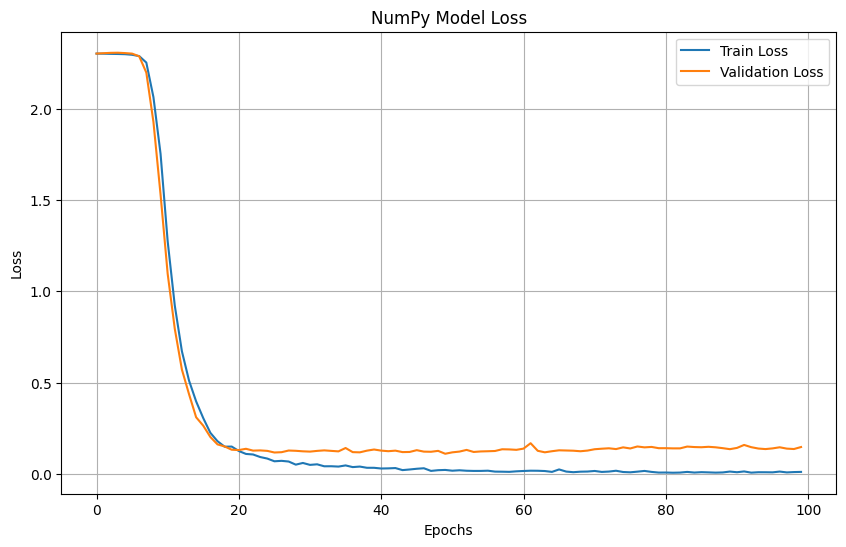

In [7]:
def plot_loss(train_losses, val_losses, title="Training and Validation Loss"):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Instantiate and train the model
numpy_model = FeedforwardNeuralNetwork(64, 128, 64, 10)
train_losses, val_losses = train_model(numpy_model, X_train, y_train, X_val, y_val, epochs=100, learning_rate=0.1, batch_size=32)

plot_loss(train_losses, val_losses, "NumPy Model Loss")

# Question 6: Save Model Weights (1 mark)

In [8]:
import pickle

# Save the trained model weights
with open('numpy_model.pkl', 'wb') as f:
    pickle.dump({
        'W1': numpy_model.W1, 'b1': numpy_model.b1,
        'W2': numpy_model.W2, 'b2': numpy_model.b2,
        'W3': numpy_model.W3, 'b3': numpy_model.b3
    }, f)

# Question 7: Load Weights and Evaluate on Test Set (2 marks)

Load the saved weights and perform comprehensive evaluation on the test set.
Report accuracy, precision, recall, and confusion matrix.

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

# Load weights into a new model instance
loaded_model = FeedforwardNeuralNetwork(64, 128, 64, 10)
with open('numpy_model.pkl', 'rb') as f:
    weights = pickle.load(f)
    loaded_model.W1 = weights['W1']
    loaded_model.b1 = weights['b1']
    loaded_model.W2 = weights['W2']
    loaded_model.b2 = weights['b2']
    loaded_model.W3 = weights['W3']
    loaded_model.b3 = weights['b3']

# Perform inference on test set
y_pred_np = loaded_model.predict(X_test)

# Calculate metrics
acc_np = accuracy_score(y_test, y_pred_np)
prec_np = precision_score(y_test, y_pred_np, average='weighted')
rec_np = recall_score(y_test, y_pred_np, average='weighted')

print(f"NumPy Model - Accuracy: {acc_np:.4f}")
print(f"NumPy Model - Precision: {prec_np:.4f}")
print(f"NumPy Model - Recall: {rec_np:.4f}")

NumPy Model - Accuracy: 0.9741
NumPy Model - Precision: 0.9743
NumPy Model - Recall: 0.9741


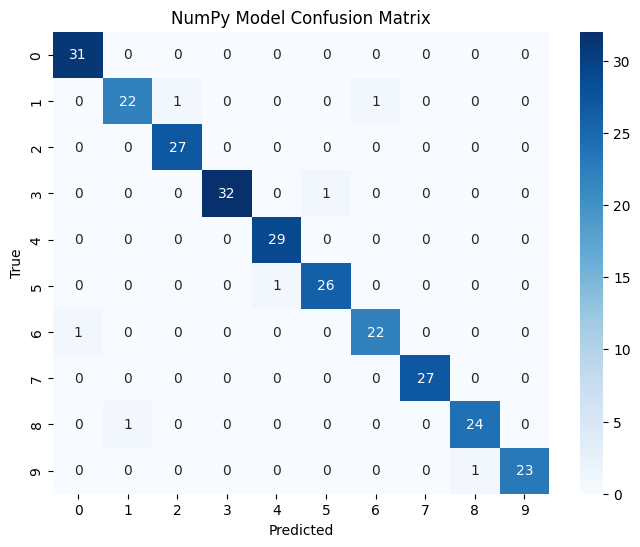

In [10]:
# Confusion Matrix
cm_np = confusion_matrix(y_test, y_pred_np)
plt.figure(figsize=(8,6))
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues')
plt.title("NumPy Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Question 8: PyTorch Implementation (3 marks)

Implement a fully connected feedforward neural network from scratch using Pytorch. Architecture:

    Input layer: 64 features (8x8 pixels)
    Hidden layer 1: 128 neurons with ReLU activation and dropout
    Hidden layer 2: 64 neurons with ReLU activation and dropout
    Output layer: 10 neurons with softmax activation

Key implementations:

    Softmax activation function
    Gradient through softmax
    Dropout regularization


In [11]:
import torch
import torch.nn as nn

class PyTorchNN(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size, dropout_rate=0.2):
        super(PyTorchNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, output_size)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # Softmax is included in CrossEntropyLoss
        return x

# Question 9: Train PyTorch Model and Save the Trained Model Weights (2 marks):

In [12]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert data
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model_pt = PyTorchNN(64, 128, 64, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

train_losses_pt = []
val_losses_pt = []

epochs = 100
for epoch in range(epochs):
    model_pt.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_pt(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    train_losses_pt.append(running_loss / len(train_loader))
    
    model_pt.eval()
    with torch.no_grad():
        val_outputs = model_pt(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses_pt.append(val_loss.item())
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses_pt[-1]:.4f}, Val Loss: {val_loss.item():.4f}")

torch.save(model_pt.state_dict(), "pytorch_model.pth")

Epoch 10/100, Train Loss: 0.0676, Val Loss: 0.1002
Epoch 20/100, Train Loss: 0.0250, Val Loss: 0.0790
Epoch 30/100, Train Loss: 0.0158, Val Loss: 0.0755
Epoch 40/100, Train Loss: 0.0065, Val Loss: 0.0718
Epoch 50/100, Train Loss: 0.0107, Val Loss: 0.0851
Epoch 60/100, Train Loss: 0.0062, Val Loss: 0.0679
Epoch 70/100, Train Loss: 0.0107, Val Loss: 0.0717
Epoch 80/100, Train Loss: 0.0043, Val Loss: 0.0773
Epoch 90/100, Train Loss: 0.0016, Val Loss: 0.0674
Epoch 100/100, Train Loss: 0.0012, Val Loss: 0.0737


# Question 10: Load and Evaluate PyTorch Model (2 marks)

In [13]:
# Load weights into a new model
loaded_model_pt = PyTorchNN(64, 128, 64, 10).to(device)
loaded_model_pt.load_state_dict(torch.load("pytorch_model.pth"))
loaded_model_pt.eval()

# Perform inference on test set
with torch.no_grad():
    outputs = loaded_model_pt(X_test_t)
    _, y_pred_pt = torch.max(outputs, 1)

y_pred_pt = y_pred_pt.cpu().numpy()

# Calculate metrics
acc_pt = accuracy_score(y_test, y_pred_pt)
prec_pt = precision_score(y_test, y_pred_pt, average='weighted')
rec_pt = recall_score(y_test, y_pred_pt, average='weighted')

print(f"PyTorch Model - Accuracy: {acc_pt:.4f}")
print(f"PyTorch Model - Precision: {prec_pt:.4f}")
print(f"PyTorch Model - Recall: {rec_pt:.4f}")

PyTorch Model - Accuracy: 0.9926
PyTorch Model - Precision: 0.9929
PyTorch Model - Recall: 0.9926


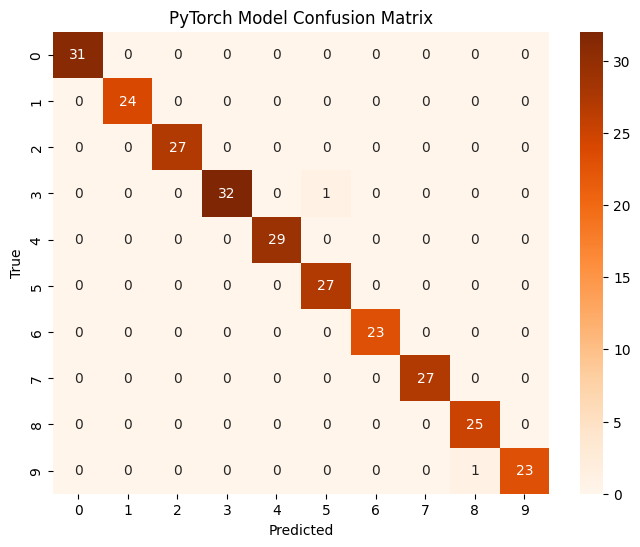

In [14]:
# Confusion Matrix
cm_pt = confusion_matrix(y_test, y_pred_pt)
plt.figure(figsize=(8,6))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Oranges')
plt.title("PyTorch Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Question 11: Performance Comparison (1 mark)

Compare the performance of NumPy and PyTorch implementations.

Accuracy Score Comparison on Test Set
NumPy Implementation:    0.9741
PyTorch Implementation:  0.9926
Difference:              0.0185


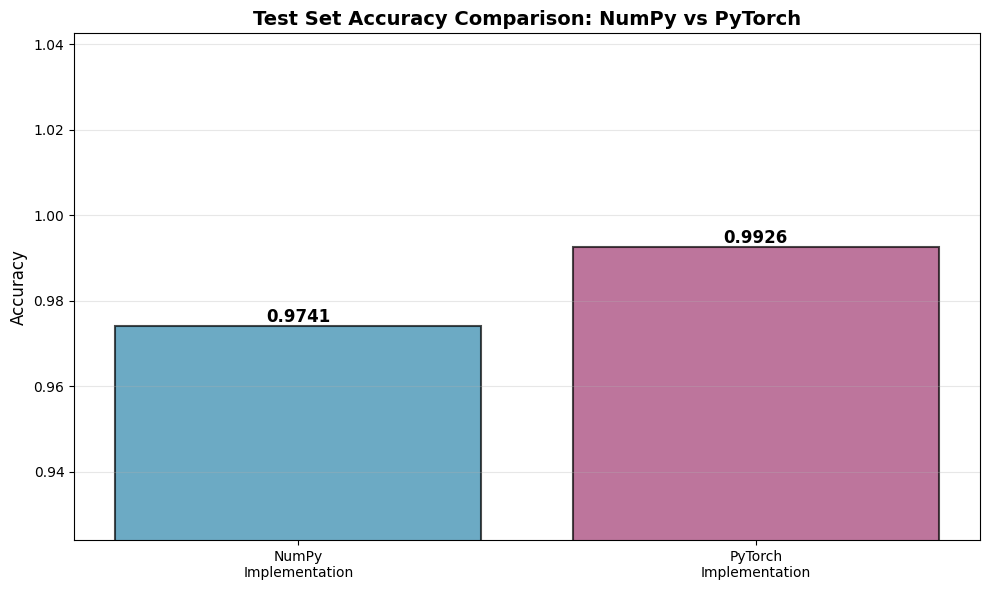

In [15]:
print("=" * 60)
print("Accuracy Score Comparison on Test Set")
print("=" * 60)
print(f"NumPy Implementation:    {acc_np:.4f}")
print(f"PyTorch Implementation:  {acc_pt:.4f}")
print(f"Difference:              {abs(acc_pt - acc_np):.4f}")
print("=" * 60)

# Create a bar chart for comparison
plt.figure(figsize=(10, 6))
models_comparison = ['NumPy\nImplementation', 'PyTorch\nImplementation']
acc_values = [acc_np, acc_pt]
colors = ['#2E86AB', '#A23B72']

bars = plt.bar(models_comparison, acc_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, value in zip(bars, acc_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{value:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Accuracy', fontsize=12)
plt.title('Test Set Accuracy Comparison: NumPy vs PyTorch', fontsize=14, fontweight='bold')
plt.ylim([min(acc_values) - 0.05, max(acc_values) + 0.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()